【1. 连续值相关性分析与辅酶公平性校正】

▶ DLKcat 辅酶校正分析:
  被剔除的辅酶频数:
cofactor
NADP    368
NAD      28

▶ UniKP 辅酶校正分析:
  被剔除的辅酶频数:
cofactor
NADP    212
NAD     184

▶ CataPro 辅酶校正分析:
  被剔除的辅酶频数:
cofactor
NADP    368
NAD      28


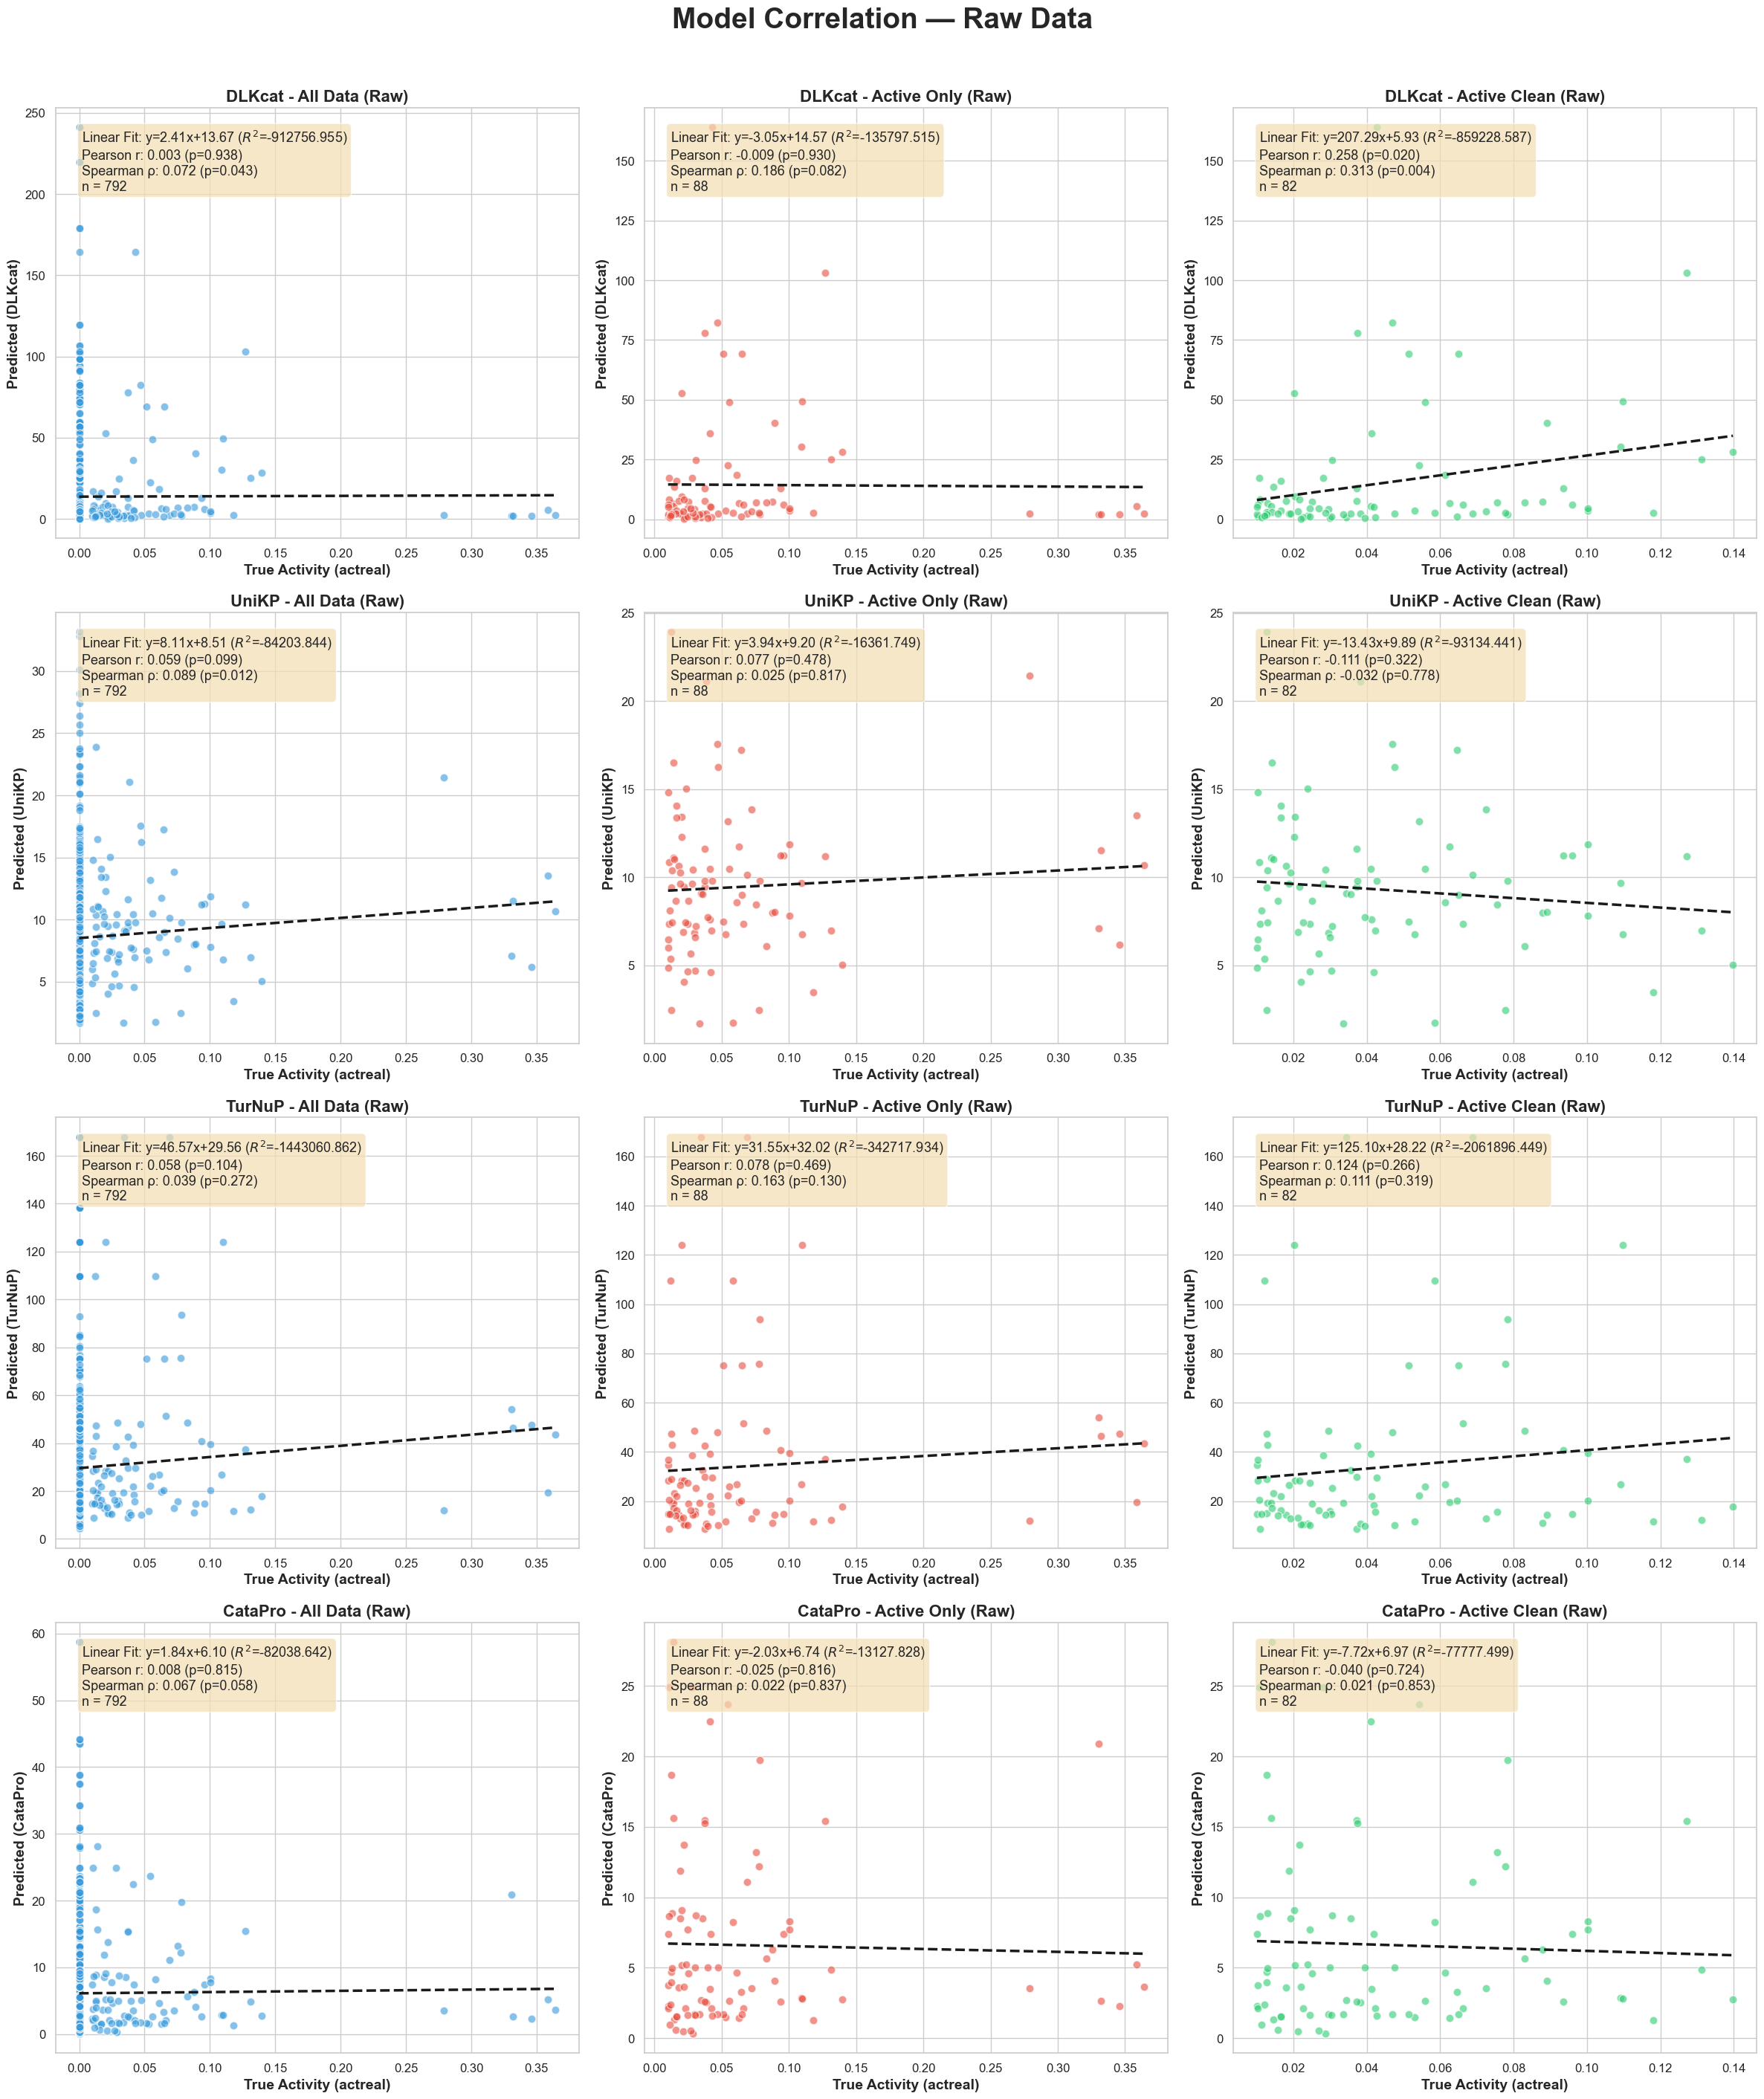

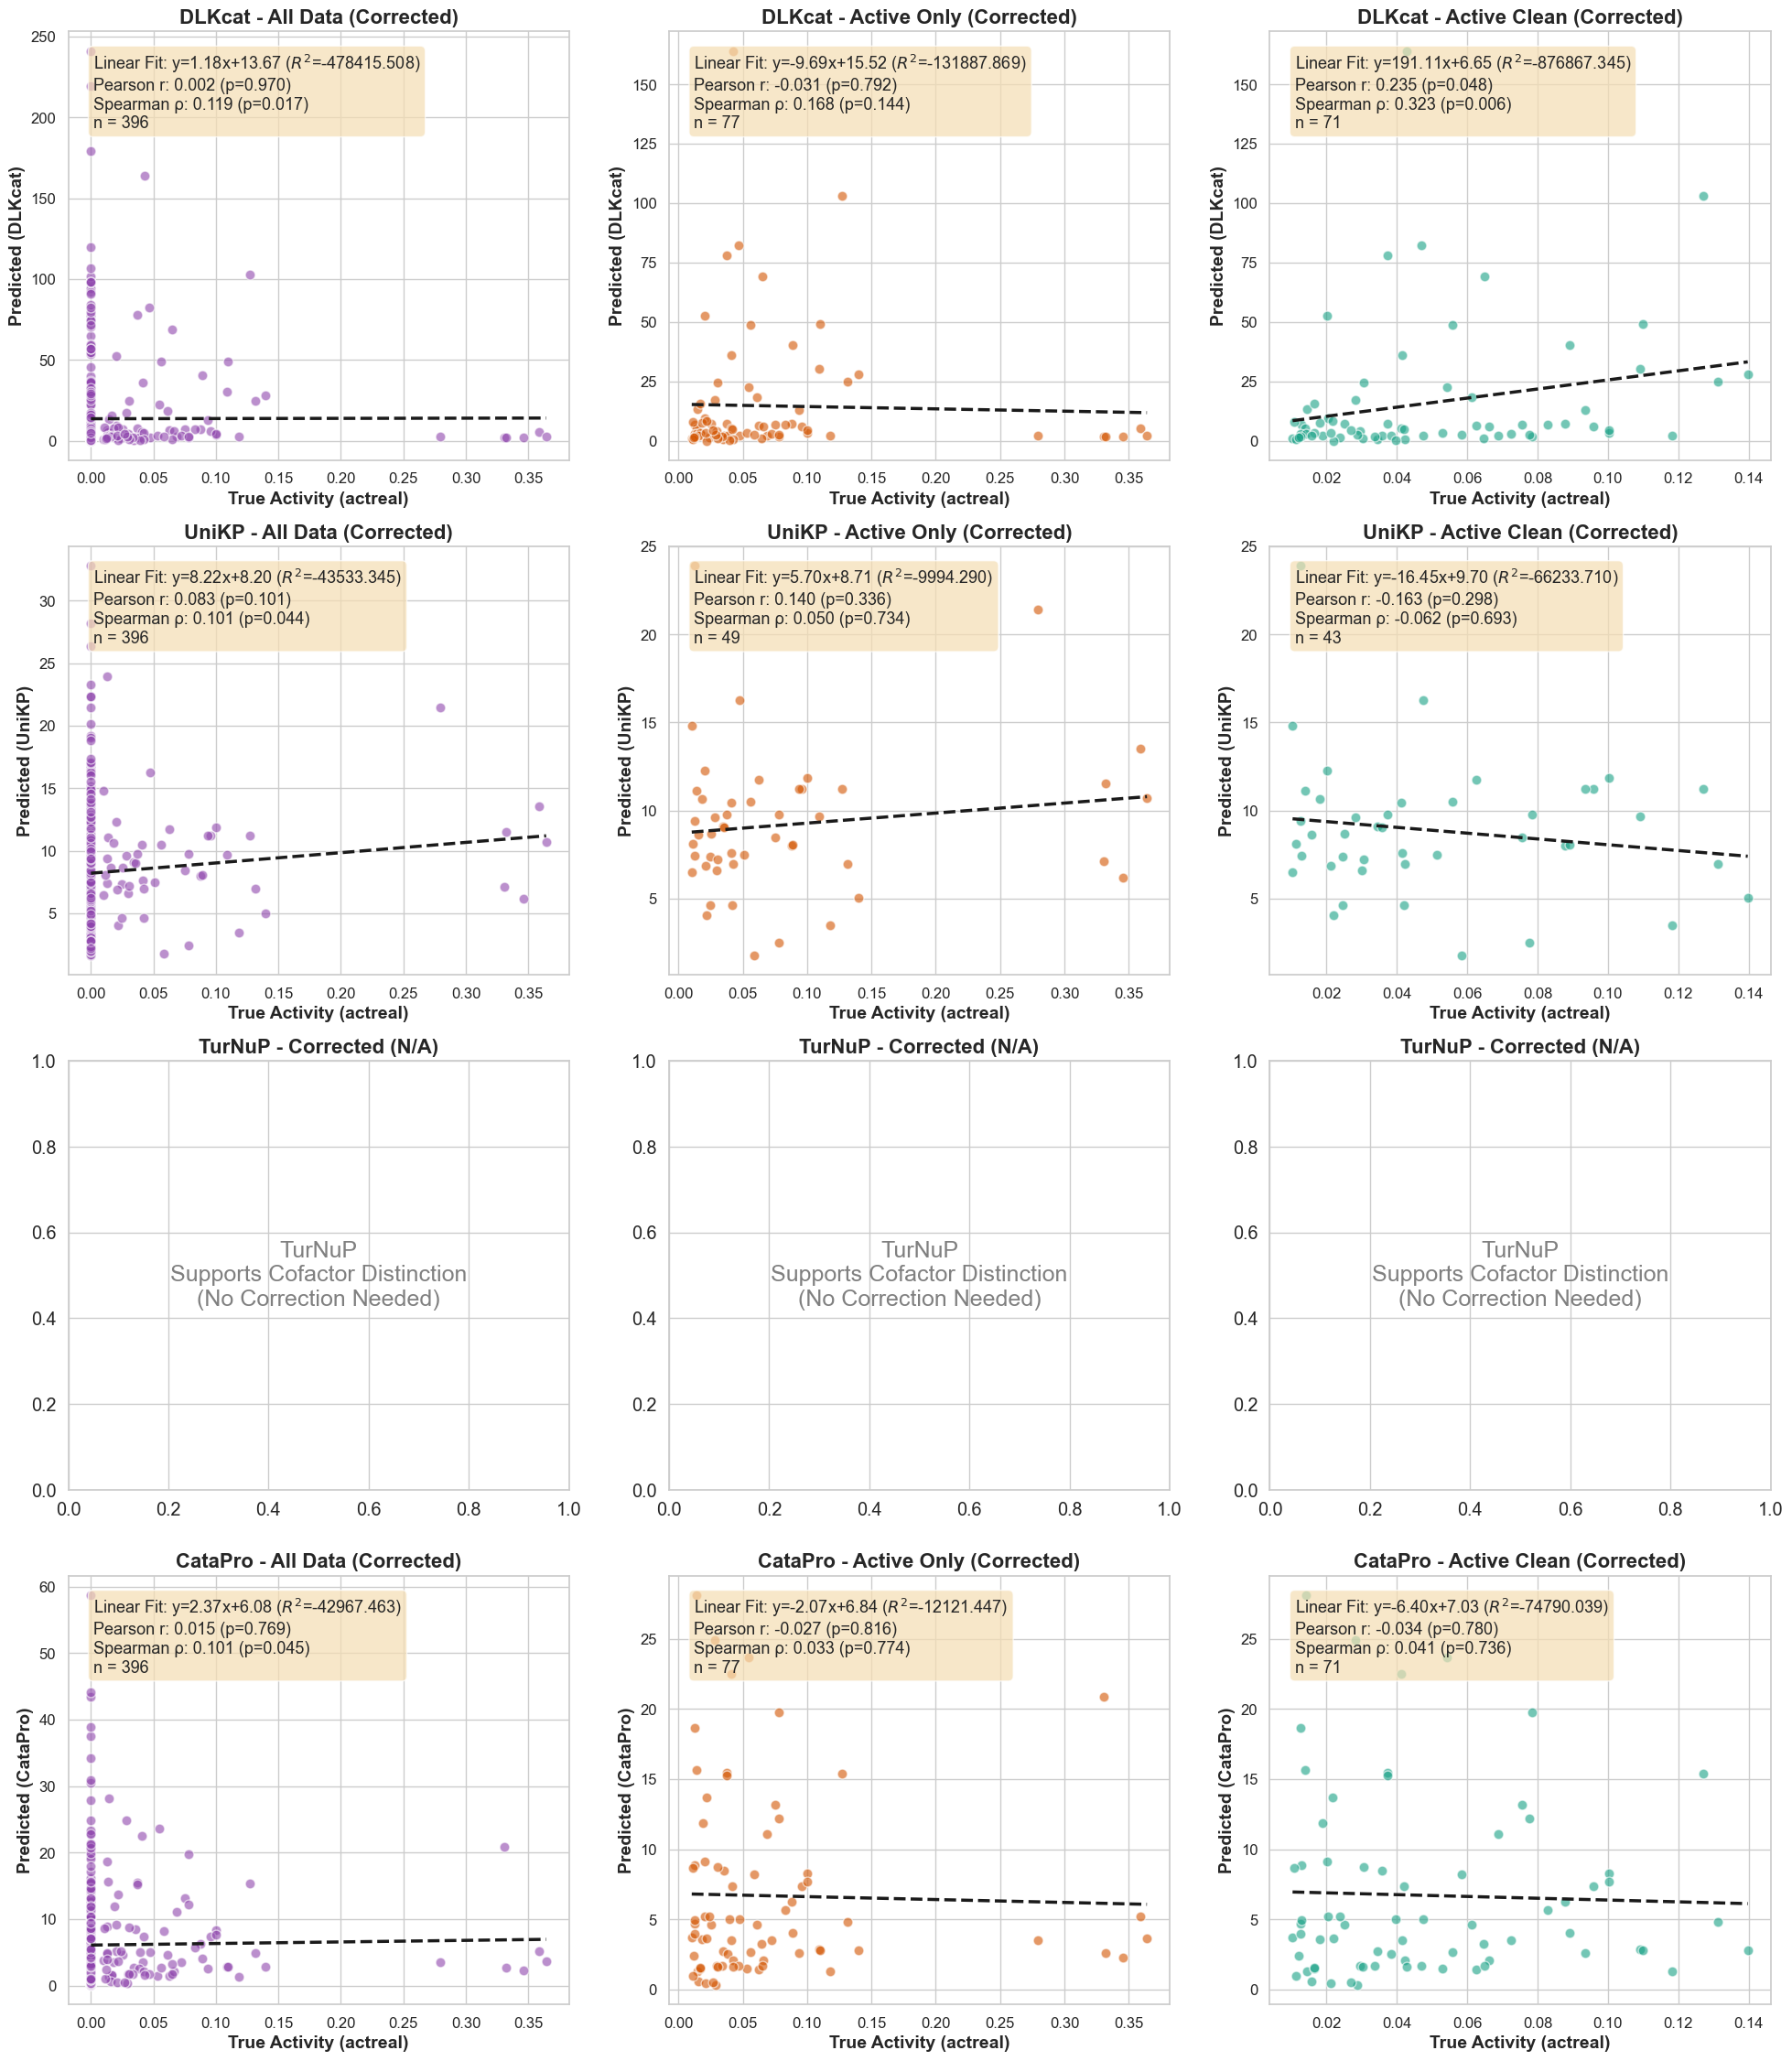


✅ FS1 已保存: figures\FS1.png
✅ FS1 已保存: figures\FS1.tif

✅ FS2 已保存: figures\FS2.png
✅ FS2 已保存: figures\FS2.tif

【2. 最佳截断值优化 (最大化 F1-Score) 与二分类指标】
✅ 阈值与二分类指标已保存: evaluation_threshold_metrics.xlsx
  Model            Dataset  Best Threshold  Accuracy  Precision  F1-Score  TP  TN  FP  FN
 DLKcat           Raw Data          4.3534    0.6566     0.1667    0.2527  46 474 230  42
 DLKcat Cofactor Corrected          4.3534    0.6591     0.2899    0.3721  40 221  98  37
  UniKP           Raw Data          6.6042    0.4306     0.1406    0.2395  71 270 434  17
  UniKP Cofactor Corrected          6.4827    0.4470     0.1627    0.2724  41 136 211   8
 TurNuP           Raw Data          9.9700    0.2020     0.1201    0.2139  86  74 630   2
CataPro           Raw Data          1.3055    0.3131     0.1334    0.2338  83 165 539   5
CataPro Cofactor Corrected          1.3055    0.3838     0.2315    0.3711  72  80 239   5
✅ 相关性指标已保存: evaluation_correlation_metrics.xlsx


In [1]:
import pandas as pd
import numpy as np
from scipy import stats
from sklearn.metrics import f1_score, confusion_matrix, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

# ==========================
# 0. 全局配置
# ==========================
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(style="whitegrid", font_scale=1.3)

# 创建保存目录
save_dir = "figures"
os.makedirs(save_dir, exist_ok=True)

# 定义需要评估的预测模型列名
PRED_COLS = ['actdlkcat', 'actunikp', 'actturnup', 'actcatapro']
MODEL_NAMES = {
    'actdlkcat': 'DLKcat',
    'actunikp': 'UniKP',
    'actturnup': 'TurNuP',
    'actcatapro': 'CataPro'
}

MODELS_NEED_CORRECTION = ['actdlkcat', 'actunikp', 'actcatapro']
OUTLIER_THRESHOLD = 0.25 

def calc_metrics_and_plot(x, y, ax, title, color, label_prefix):
    """辅助函数：计算指标、绘制散点图及回归线、添加图注"""
    if len(x) < 3:
        ax.text(0.5, 0.5, "Insufficient Data", transform=ax.transAxes,
                fontsize=16, ha='center', va='center', color='gray')
        ax.set_title(title, fontsize=16, fontweight='bold')
        return None
        
    p_r, p_p = stats.pearsonr(x, y)
    s_r, s_p = stats.spearmanr(x, y)
    r2 = r2_score(x, y)
    
    ax.scatter(x, y, alpha=0.6, edgecolors='w', s=60, color=color)
    z = np.polyfit(x, y, 1)
    p = np.poly1d(z)
    x_line = np.linspace(x.min(), x.max(), 100)
    ax.plot(x_line, p(x_line), "k--", lw=2.5)
    
    p_p_str = f"{p_p:.2e}" if p_p < 0.001 else f"{p_p:.3f}"
    s_p_str = f"{s_p:.2e}" if s_p < 0.001 else f"{s_p:.3f}"
    
    textstr = (f'Linear Fit: y={z[0]:.2f}x+{z[1]:.2f} ($R^2$={r2:.3f})\n'
               f'Pearson r: {p_r:.3f} (p={p_p_str})\n'
               f'Spearman ρ: {s_r:.3f} (p={s_p_str})\n'
               f'n = {len(x)}')
    props = dict(boxstyle='round', facecolor='wheat', alpha=0.7)
    ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=13,
            verticalalignment='top', bbox=props)
            
    ax.set_xlabel("True Activity (actreal)", fontsize=14, fontweight='bold')
    ax.set_ylabel(f"Predicted ({label_prefix})", fontsize=14, fontweight='bold')
    ax.set_title(title, fontsize=16, fontweight='bold')
    ax.tick_params(axis='both', which='major', labelsize=12)
    
    return {'Pearson_r': p_r, 'Pearson_p': p_p, 'Spearman_r': s_r, 'Spearman_p': s_p, 'R2': r2, 'n': len(x)}

def apply_cofactor_correction(df, col):
    """辅酶校正"""
    df_valid = df[[col, 'actreal', 'enzyme', 'subnum', 'cofactor']].dropna().copy()
    df_valid['abs_error'] = np.abs(df_valid[col] - df_valid['actreal'])
    idx_to_keep = df_valid.groupby(['enzyme', 'subnum'])['abs_error'].idxmin()
    df_corrected = df_valid.loc[idx_to_keep]
    removed_df = df_valid.loc[~df_valid.index.isin(idx_to_keep)]
    removed_counts = removed_df['cofactor'].value_counts()
    return df_corrected.index, removed_counts

def evaluate_binary_metrics(y_true_bin, y_pred_cont, model_name, dataset_label):
    """计算二分类指标"""
    thresholds = np.unique(y_pred_cont)
    if len(thresholds) > 1000:
        thresholds = np.linspace(y_pred_cont.min(), y_pred_cont.max(), 1000)
    best_f1, best_thresh = -1, 0
    for thresh in thresholds:
        y_pred_bin = (y_pred_cont >= thresh).astype(int)
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            f1 = f1_score(y_true_bin, y_pred_bin, zero_division=0)
        if f1 > best_f1:
            best_f1, best_thresh = f1, thresh
    y_pred_final = (y_pred_cont >= best_thresh).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true_bin, y_pred_final, labels=[0, 1]).ravel()
    total = tp + tn + fp + fn
    return {
        'Model': model_name, 'Dataset': dataset_label, 'Best Threshold': best_thresh,
        'Accuracy': (tp + tn) / total if total > 0 else 0,
        'Precision': tp / (tp + fp) if (tp + fp) > 0 else 0,
        'F1-Score': best_f1,
        'TPR (Recall)': tp / (tp + fn) if (tp + fn) > 0 else 0,
        'TNR (Specificity)': tn / (tn + fp) if (tn + fp) > 0 else 0,
        'TP': tp, 'TN': tn, 'FP': fp, 'FN': fn
    }

def evaluate_predictions(filepath: str = "sum.xlsx"):
    df = pd.read_excel(filepath)
    
    if 'substrate_class' not in df.columns and 'subnum' in df.columns:
        def simple_classify(subnum):
            if 1 <= subnum <= 12: return "Aliphatic alcohols"
            elif 13 <= subnum <= 20: return "Saccharides & polyols"
            elif 21 <= subnum <= 24: return "Aromatic alcohols"
            elif 25 <= subnum <= 28: return "Heterocyclic alcohols"
            elif 29 <= subnum <= 32: return "Cyclohexanol derivatives"
            else: return "Others"
        df['substrate_class'] = df['subnum'].apply(simple_classify)

    if 'actreal' not in df.columns or 'actbool' not in df.columns:
        raise ValueError("输入文件必须包含 'actreal' 和 'actbool' 列！")
        
    y_true_cont = df['actreal'].values
    y_true_bin = df['actbool'].values
    
    threshold_results = []
    valid_models = [col for col in PRED_COLS if col in df.columns and (~df[col].isna() & ~df['actreal'].isna()).sum() > 0]
    
    if not valid_models:
        print("🚨 没有任何有效的预测模型数据，程序终止。"); return

    # =============================================
    # 初始化两个独立的 4×3 图：FS1 (Raw) 和 FS2 (Corrected)
    # =============================================
    fig_raw, axes_raw = plt.subplots(4, 3, figsize=(24, 28))   # FS1: 左半部分 (原始数据)
    fig_corr, axes_corr = plt.subplots(4, 3, figsize=(24, 28))  # FS2: 右半部分 (校正数据)
    
    all_corr_results = []

    print("=" * 70)
    print("【1. 连续值相关性分析与辅酶公平性校正】")
    print("=" * 70)
    
    for i, col in enumerate(valid_models):
        model_name = MODEL_NAMES[col]
        mask_all = ~df[col].isna() & ~df['actreal'].isna()
        
        # ==============================
        # FS1: 原始数据 (3列: All / Active Only / Active Clean)
        # ==============================
        # All Data (Raw)
        x_all = y_true_cont[mask_all]; y_all = df[col].values[mask_all]
        res = calc_metrics_and_plot(x_all, y_all, axes_raw[i, 0], 
                                     f"{model_name} - All Data (Raw)", '#3498db', model_name)
        if res: res.update({'Model': model_name, 'Dataset': 'All (Raw)'}); all_corr_results.append(res)
            
        # Active Only (Raw)
        mask_act = mask_all & (df['actbool'].values == 1)
        x_act = y_true_cont[mask_act]; y_act = df[col].values[mask_act]
        res = calc_metrics_and_plot(x_act, y_act, axes_raw[i, 1], 
                                     f"{model_name} - Active Only (Raw)", '#e74c3c', model_name)
        if res: res.update({'Model': model_name, 'Dataset': 'Active Only (Raw)'}); all_corr_results.append(res)
            
        # Active Clean (Raw)
        mask_clean = mask_act & (y_true_cont <= OUTLIER_THRESHOLD)
        x_clean = y_true_cont[mask_clean]; y_clean = df[col].values[mask_clean]
        res = calc_metrics_and_plot(x_clean, y_clean, axes_raw[i, 2], 
                                     f"{model_name} - Active Clean (Raw)", '#2ecc71', model_name)
        if res: res.update({'Model': model_name, 'Dataset': 'Active Clean (Raw)'}); all_corr_results.append(res)

        # 记录第一轮二分类指标
        threshold_results.append(evaluate_binary_metrics(
            y_true_bin[mask_all], df[col].values[mask_all], model_name, 'Raw Data'))

        # ==============================
        # FS2: 辅酶校正数据 (3列: All / Active Only / Active Clean)
        # ==============================
        if col in MODELS_NEED_CORRECTION:
            print(f"\n▶ {model_name} 辅酶校正分析:")
            corrected_idx, removed_counts = apply_cofactor_correction(df, col)
            print(f"  被剔除的辅酶频数:\n{removed_counts.to_string()}")
            
            # All Data (Corrected)
            mask_corr_all = df.index.isin(corrected_idx)
            x_c_all = y_true_cont[mask_corr_all]; y_c_all = df[col].values[mask_corr_all]
            res = calc_metrics_and_plot(x_c_all, y_c_all, axes_corr[i, 0], 
                                         f"{model_name} - All Data (Corrected)", '#8e44ad', model_name)
            if res: res.update({'Model': model_name, 'Dataset': 'All (Corrected)'}); all_corr_results.append(res)
            
            # Active Only (Corrected)
            mask_corr_act = mask_corr_all & (df['actbool'].values == 1)
            x_c_act = y_true_cont[mask_corr_act]; y_c_act = df[col].values[mask_corr_act]
            res = calc_metrics_and_plot(x_c_act, y_c_act, axes_corr[i, 1], 
                                         f"{model_name} - Active Only (Corrected)", '#d35400', model_name)
            if res: res.update({'Model': model_name, 'Dataset': 'Active Only (Corrected)'}); all_corr_results.append(res)
            
            # Active Clean (Corrected)
            mask_corr_clean = mask_corr_act & (y_true_cont <= OUTLIER_THRESHOLD)
            x_c_clean = y_true_cont[mask_corr_clean]; y_c_clean = df[col].values[mask_corr_clean]
            res = calc_metrics_and_plot(x_c_clean, y_c_clean, axes_corr[i, 2], 
                                         f"{model_name} - Active Clean (Corrected)", '#16a085', model_name)
            if res: res.update({'Model': model_name, 'Dataset': 'Active Clean (Corrected)'}); all_corr_results.append(res)
            
            # 记录第二轮二分类指标
            threshold_results.append(evaluate_binary_metrics(
                y_true_bin[mask_corr_all], df[col].values[mask_corr_all], model_name, 'Cofactor Corrected'))
        else:
            # TurNuP 不需要校正，后3列留白并添加说明
            for j in range(3):
                axes_corr[i, j].text(0.5, 0.5, 
                    f"{model_name}\nSupports Cofactor Distinction\n(No Correction Needed)", 
                    transform=axes_corr[i, j].transAxes, fontsize=18, ha='center', va='center', color='gray')
                axes_corr[i, j].set_title(f"{model_name} - Corrected (N/A)", fontsize=16, fontweight='bold')

    # ==============================
    # 保存 FS1 (原始数据)
    # ==============================
    fig_raw.suptitle("Model Correlation — Raw Data", fontsize=28, fontweight='bold', y=1.01)
    fig_raw.tight_layout()
    fs1_png = os.path.join(save_dir, "FS1.png")
    fs1_tif = os.path.join(save_dir, "FS1.tif")
    fig_raw.savefig(fs1_png, dpi=300, bbox_inches='tight')
    fig_raw.savefig(fs1_tif, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"\n✅ FS1 已保存: {fs1_png}")
    print(f"✅ FS1 已保存: {fs1_tif}")

    # ==============================
    # 保存 FS2 (辅酶校正数据)
    # ==============================
    fig_corr.suptitle("Model Correlation — Cofactor Corrected", fontsize=28, fontweight='bold', y=1.01)
    fig_corr.tight_layout()
    fs2_png = os.path.join(save_dir, "FS2.png")
    fs2_tif = os.path.join(save_dir, "FS2.tif")
    fig_corr.savefig(fs2_png, dpi=300, bbox_inches='tight')
    fig_corr.savefig(fs2_tif, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"\n✅ FS2 已保存: {fs2_png}")
    print(f"✅ FS2 已保存: {fs2_tif}")

    # ==============================
    # 保存评估结果
    # ==============================
    print("\n" + "=" * 70)
    print("【2. 最佳截断值优化 (最大化 F1-Score) 与二分类指标】")
    print("=" * 70)
    
    thresh_df = pd.DataFrame(threshold_results)
    thresh_df.to_excel("evaluation_threshold_metrics.xlsx", index=False)
    print("✅ 阈值与二分类指标已保存: evaluation_threshold_metrics.xlsx")
    
    display_cols = ['Model', 'Dataset', 'Best Threshold', 'Accuracy', 'Precision', 'F1-Score', 'TP', 'TN', 'FP', 'FN']
    print(thresh_df[display_cols].to_string(index=False, float_format="%.4f"))

    corr_df = pd.DataFrame(all_corr_results)
    corr_df.to_excel("evaluation_correlation_metrics.xlsx", index=False)
    print("✅ 相关性指标已保存: evaluation_correlation_metrics.xlsx")

if __name__ == "__main__":
    evaluate_predictions("sum.xlsx")

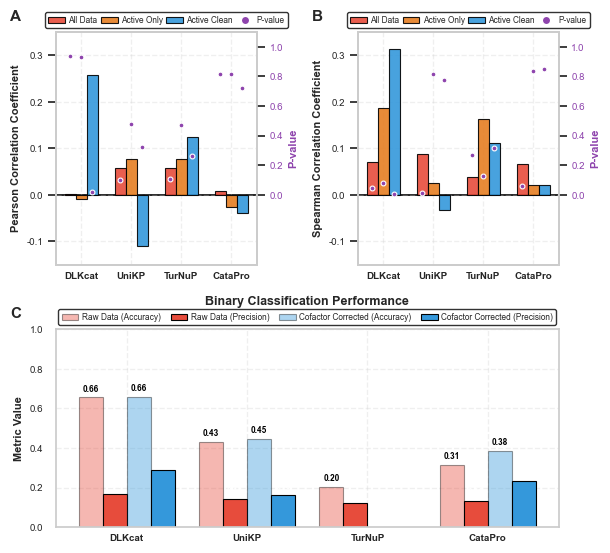

✅ Figure3 已保存: figures\Figure3.png
✅ Figure3 已保存: figures\Figure3.tif


In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.transforms as transforms
import matplotlib.font_manager as fm
import os
import warnings
warnings.filterwarnings('ignore')

# ==========================================
# 0. 强制全局字体为 Arial
# ==========================================
arial_path = None
for f in fm.fontManager.ttflist:
    if 'Arial' in f.name and 'Italic' not in f.name and 'Bold' not in f.name:
        arial_path = f.fname
        break

if arial_path:
    prop = fm.FontProperties(fname=arial_path)
    plt.rcParams['font.family'] = prop.get_name()
else:
    plt.rcParams['font.family'] = 'sans-serif'
    plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans']
    
plt.rcParams['axes.unicode_minus'] = False

# ==========================================
# 1. 读取数据与基础设置
# ==========================================
corr_df = pd.read_excel("evaluation_correlation_metrics.xlsx")
thresh_df = pd.read_excel("evaluation_threshold_metrics.xlsx")

save_dir = "figures"
os.makedirs(save_dir, exist_ok=True)
model_order = ['DLKcat', 'UniKP', 'TurNuP', 'CataPro']

# ==========================================
# 2. 核心绘图逻辑封装
# ==========================================
def main_plotting_routine(CONFIG):
    # ==========================================
    # 3. 创建 Figure 与 GridSpec
    # ==========================================
    fig3 = plt.figure(figsize=(CONFIG['fig_width'], CONFIG['fig_height']))
    gs = gridspec.GridSpec(
        2, 2, figure=fig3,
        height_ratios=CONFIG['height_ratios'],
        width_ratios=CONFIG['width_ratios'],
        hspace=CONFIG['h_pad'],
        wspace=CONFIG['w_pad']
    )

    # ==========================================
    # 4. 辅助函数：图号绝对定位
    # ==========================================
    def add_subplot_label(ax, label):
        offset = transforms.ScaledTranslation(
            CONFIG['label_dx_pts'] / 72, 
            CONFIG['label_dy_pts'] / 72, 
            fig3.dpi_scale_trans
        )
        trans = ax.transAxes + offset
        ax.text(0, 1.0, label, transform=trans,
                fontsize=CONFIG['label_fontsize'], fontweight='bold', va='bottom', ha='right')

    # ==========================================
    # 5. 公共数据准备
    # ==========================================
    x = np.arange(len(model_order))
    width = 0.22  

    datasets_corr_internal = ['All (Raw)', 'Active Only (Raw)', 'Active Clean (Raw)']
    datasets_corr_display = ['All Data', 'Active Only', 'Active Clean']
    
    base_colors = CONFIG['colors_raw'] 
    colors_raw = base_colors

    left_ymin, left_ymax = -0.15, 0.35
    zero_ratio = (0 - left_ymin) / (left_ymax - left_ymin)
    right_ymax = 1.1
    right_ymin = - (right_ymax * zero_ratio) / (1 - zero_ratio)

    title_fs   = CONFIG['title']
    axlabel_fs = CONFIG['axis_label']
    tick_fs    = CONFIG['tick_label']
    pval_s     = CONFIG['pvalue_markersize']
    pval_lw    = CONFIG['pvalue_linewidth']
    pval_color = CONFIG['pvalue_color']
    
    light_alpha = CONFIG['light_color_alpha']
    
    # 提取刻度间距参数
    x_pad = CONFIG['xtick_pad']
    y_pad_l = CONFIG['ytick_pad_left']
    y_pad_r = CONFIG['ytick_pad_right']

    # ==========================================
    # 6. 通用绘图函数：相关系数子图 (A/B)
    # ==========================================
    def plot_correlation_subplot(ax, corr_type, r_col, p_col, ylabel_text, config):
        # 精准控制主左轴网格线 (水平+垂直)
        ax.yaxis.grid(True, linestyle='--', alpha=0.3, zorder=0)
        ax.xaxis.grid(True, linestyle='--', alpha=0.3, zorder=0)
        
        ax.set_ylabel(ylabel_text, fontsize=axlabel_fs, fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels(model_order, fontsize=tick_fs, fontweight='bold')
        
        # 【新增】：应用 X轴 和 左Y轴 的刻度间距
        ax.tick_params(axis='x', pad=x_pad)
        ax.tick_params(axis='y', labelsize=tick_fs, pad=y_pad_l)
        
        ax.set_ylim(left_ymin, left_ymax)
        ax.set_yticks([-0.1, 0.0, 0.1, 0.2, 0.3])
        ax.axhline(0, color='black', linewidth=1.2, linestyle='-', zorder=0)

        ax_p = ax.twinx()
        ax_p.grid(False)
        
        ax_p.set_ylabel('P-value', fontsize=axlabel_fs, color=pval_color, fontweight='bold')
        ax_p.set_ylim(right_ymin, right_ymax)
        ax_p.set_yticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
        
        # 【新增】：应用 右Y轴(P-value) 的刻度间距
        ax_p.tick_params(axis='y', labelcolor=pval_color, labelsize=tick_fs, pad=y_pad_r)

        for i, (ds_int, ds_disp) in enumerate(zip(datasets_corr_internal, datasets_corr_display)):
            df_sub = corr_df[corr_df['Dataset'] == ds_int].set_index('Model').reindex(model_order)
            r_vals = df_sub[r_col].values
            p_vals = np.clip(df_sub[p_col].values, 0, 1)

            ax.bar(x + i*width - width, r_vals, width, label=ds_disp,
                   color=colors_raw[i], alpha=0.9, edgecolor='black', linewidth=0.8)
            ax_p.scatter(x + i*width - width, p_vals, color=pval_color,
                         marker='o', s=pval_s, zorder=5, edgecolors='white', linewidth=pval_lw)
        
        handles, labels = ax.get_legend_handles_labels()
        p_handle = plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=pval_color,
                              markeredgecolor='white', markersize=6, label='P-value')
        handles.append(p_handle)
        
        ax.legend(handles=handles, fontsize=config['legend_fontsize_AB'], loc='lower center',
                  bbox_to_anchor=(config['legend_x_offset_AB'], config['legend_y_offset_AB']),
                  ncol=4, frameon=True, edgecolor='black', facecolor='white',
                  columnspacing=config['legend_columnspacing_AB'], handletextpad=0.4)

    # ==========================================
    # 7. 绘制子图 A 与 B
    # ==========================================
    ax_pearson = fig3.add_subplot(gs[0, 0])
    add_subplot_label(ax_pearson, 'A')
    plot_correlation_subplot(ax_pearson, 'Pearson', 'Pearson_r', 'Pearson_p',
                             'Pearson Correlation Coefficient', CONFIG)

    ax_spearman = fig3.add_subplot(gs[0, 1])
    add_subplot_label(ax_spearman, 'B')
    plot_correlation_subplot(ax_spearman, 'Spearman', 'Spearman_r', 'Spearman_p',
                             'Spearman Correlation Coefficient', CONFIG)

    # ==========================================
    # 8. 绘制子图 C: 二分类能力对比
    # ==========================================
    ax_binary = fig3.add_subplot(gs[1, :])
    add_subplot_label(ax_binary, 'C')
    
    ax_binary.yaxis.grid(True, linestyle='--', alpha=0.3, zorder=0)
    ax_binary.xaxis.grid(True, linestyle='--', alpha=0.3, zorder=0)

    ax_binary.set_title('Binary Classification Performance',
                        fontsize=title_fs, fontweight='bold', pad=CONFIG['title_pad_C'])
    ax_binary.set_ylabel('Metric Value', fontsize=axlabel_fs, fontweight='bold')
    
    ax_binary.set_xticks(x)
    ax_binary.set_xticklabels(model_order, fontsize=tick_fs, fontweight='bold')
    
    # 【新增】：应用图C的 X轴 和 左Y轴 刻度间距
    ax_binary.tick_params(axis='x', pad=x_pad)
    ax_binary.tick_params(axis='y', labelsize=tick_fs, pad=y_pad_l)
    
    ax_binary.set_ylim(0, 1.0)
    ax_binary.set_yticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])

    width2 = 0.2
    
    binary_color_map = {
        ('Raw Data', 'Accuracy'):           {'color_idx': 0, 'alpha': light_alpha},
        ('Raw Data', 'Precision'):          {'color_idx': 0, 'alpha': 1.0},
        ('Cofactor Corrected', 'Accuracy'): {'color_idx': 2, 'alpha': light_alpha},
        ('Cofactor Corrected', 'Precision'):{'color_idx': 2, 'alpha': 1.0},
    }

    for i, (ds, metric) in enumerate(binary_color_map.keys()):
        mapping = binary_color_map[(ds, metric)]
        bar_color = base_colors[mapping['color_idx']]
        bar_alpha = mapping['alpha']
        
        df_sub = thresh_df[(thresh_df['Dataset'] == ds) & (thresh_df['Model'].isin(model_order))].set_index('Model')
        df_sub = df_sub.reindex(model_order)
        vals = df_sub[metric].values
        
        bars = ax_binary.bar(x + i*width2 - 1.5*width2, vals, width2,
                             label=f'{ds} ({metric})', color=bar_color, alpha=bar_alpha,
                             edgecolor='black', linewidth=0.8)

        text_color = 'black' if bar_alpha < 0.8 else 'white'
        
        for bar in bars:
            height = bar.get_height()
            if not np.isnan(height) and height > 0.02:
                y_pos = height - 0.04 if height > 0.85 else height + 0.02
                va_align = 'top' if height > 0.85 else 'bottom'
                ax_binary.text(bar.get_x() + bar.get_width()/2., y_pos, f'{height:.2f}',
                               ha='center', va=va_align, fontsize=CONFIG['bar_text'],
                               fontweight='bold', color=text_color)

    ax_binary.legend(fontsize=CONFIG['legend_fontsize_C'], loc='lower center',
                     bbox_to_anchor=(0.5, CONFIG['legend_y_offset_C']),
                     ncol=4, frameon=True, edgecolor='black', facecolor='white',
                     columnspacing=1.2, handletextpad=0.4)

    # ==========================================
    # 9. 全局布局调整与保存
    # ==========================================
    plt.subplots_adjust(
        top=1 - CONFIG['margin_top'],
        bottom=CONFIG['margin_bottom'],
        left=CONFIG['margin_left'],
        right=1 - CONFIG['margin_right']
    )

    fig3_png = os.path.join(save_dir, "Figure3.png")
    fig3_tif = os.path.join(save_dir, "Figure3.tif")
    fig3.savefig(fig3_png, dpi=300, bbox_inches='tight', pad_inches=0.1)
    fig3.savefig(fig3_tif, dpi=300, bbox_inches='tight', pad_inches=0.1)
    plt.show()

    print(f"✅ Figure3 已保存: {fig3_png}")
    print(f"✅ Figure3 已保存: {fig3_tif}")


# ==========================================
# 10. 全局参数配置 (CONFIG 完美置底)
# ==========================================
CONFIG = {
    # ================= 画布与网格布局 =================
    'fig_width': 5.85, 'fig_height': 5.5,                  
    'height_ratios': [1.0, 0.85], 'width_ratios': [1.0, 1.0],         
    'margin_top': 0.02, 'margin_bottom': 0.08, 
    'margin_left': 0.10, 'margin_right': 0.04,
    'h_pad': 0.3, 'w_pad': 0.5,                      

    # ================= 全局字号 =================
    'title': 9, 'axis_label': 8, 'tick_label': 7, 'bar_text': 6,                      
    'legend_fontsize_AB': 6, 'legend_fontsize_C': 6,             

    # ================= 刻度值与坐标轴间距控制 (新增) =================
    'xtick_pad': -1,             # X轴刻度值与X轴线的距离 (数值越大离得越远)
    'ytick_pad_left': 3,        # 左侧Y轴刻度值与Y轴线的距离
    'ytick_pad_right': 3,       # 右侧Y轴(P-value)刻度值与Y轴线的距离

    # ================= 图号 A/B/C 绝对定位 (Points) =================
    'label_dx_pts': -25, 'label_dy_pts': 6, 'label_fontsize': 11,               

    # ================= P-value 散点设置 =================
    'pvalue_markersize': 12, 'pvalue_linewidth': 0.8, 'pvalue_color': '#8e44ad',          

    # ================= A/B 图例公用调节选项 =================
    'legend_x_offset_AB': 0.55,          
    'legend_columnspacing_AB': 0.4,     
    'legend_y_offset_AB': 1.0,          

    # ================= C图浅色透明度控制 =================
    'light_color_alpha': 0.4,           

    # ================= 统一基础配色 (ABC三图共用) =================
    'colors_raw': ['#e74c3c', '#e67e22', '#3498db'],  

    # ================= C图图例与标题间距控制 =================
    'title_pad_C': 18,                  
    'legend_y_offset_C': 1.0,          
}

# 执行绘图
if __name__ == "__main__":
    main_plotting_routine(CONFIG)